In [1]:
import cfe

cfe.logger.setLevel("DEBUG")
cfe.settings.backend = "dynverse_docker"

[11/03/2025 09:12:55] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

In [2]:
fadata = cfe.data.read_pancrease()
fadata

                      DEBUG    Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                      
[11/03/2025 09:12:59] DEBUG    transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                 
                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                    

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cfe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

In [3]:
import scvelo as scv

scv.pp.filter_and_normalize(fadata, n_top_genes=2000) # need optimized

[11/03/2025 09:13:00] DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                              

In [4]:
method2parameters = {
    # "ti_paga": {},
    # "ti_slingshot": {},
    "ti_tscan": {},
}

for method_name, parameters in method2parameters.items():
    parameters["repreprocess"] = False # use common preprocessing
    parameters["benchmark_resource"] = True # record resource usage
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    # save in time, without waiting for all methods to finish, waypoint are not calculated
    fadata.write_trajectory_dict(model_name_list=[fadata.model_name])

                      DEBUG    Docker image(dynverse/ti_tscan:v0.9.9.01) loaded, entry point is '['/code/run.R']'                                                                                       
[11/03/2025 09:13:03] INFO     method backend loaded: Dynverse Docker Backend: docker image 'dynverse/ti_tscan:v0.9.9.01'                                                                               
                      DEBUG    set new log file: .cfe/pancreas/log/20251103_091303__ti_tscan-dynverse_docker__vw7uxDNblZ.log                                                                            
                      DEBUG    continue logging from old file: /root/PyCode/scRNA/CellFateExplorer/CellFateExplorer/notebook_dev/hzy/.cfe/cfe_debug.log                                                 
                      DEBUG    definition input_df:           input_id  required        type                                                                                                        

                      DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    calculate new trajectory embedding for model_name:ref, basis:X_umap.                                                                                                     
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
[11/03/2025 09:13:34] DEBUG    add waypoints shape is (212, 3696) for 'ref', finished!                                                                                                              

<Axes: title={'center': 'ti_tscan-dynverse_docker(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>

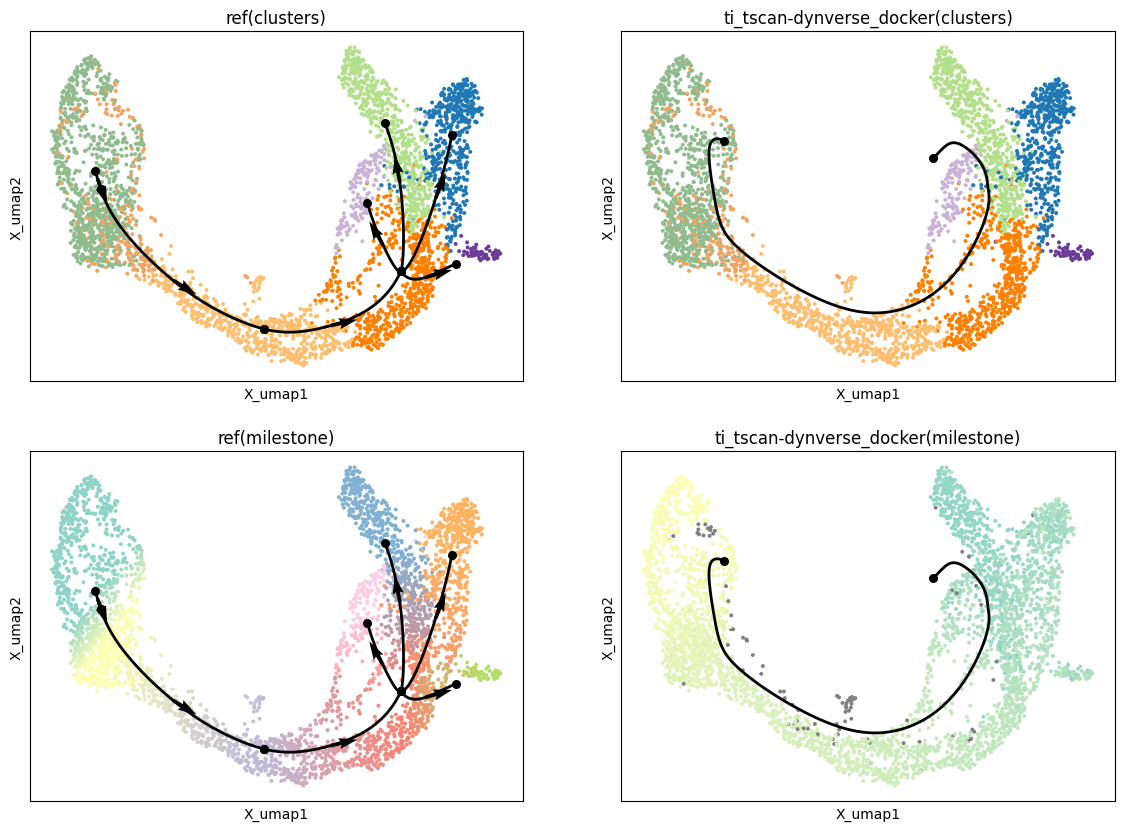

In [5]:
model_name_list = fadata.get_all_model_name(parse=False)
color_list = ["clusters", "milestone"]

cfe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

In [6]:
fadata.write_trajectory_dict() 

[11/03/2025 09:14:48] DEBUG    write trajectory 'ref' to '.cfe/pancreas/trajectory_history/ref.pkl'                                                                                                     
                      DEBUG    write trajectory '20251103_091303__ti_tscan-dynverse_docker__vw7uxDNblZ' to '.cfe/pancreas/trajectory_history/20251103_091303__ti_tscan-dynverse_docker__vw7uxDNblZ.pkl' 
